# 06_training_monitoring_and_failure_detection: Real Checkpointing, LR Scheduling, and a Real Overfitting Divergence

This notebook runs a real `gpt2` training loop instrumented with Module 07's `warmup_cosine_lr` schedule and real gradient-norm logging, verifies that checkpoint save/resume reproduces *exactly* the same continuation (not just "close enough"), and deliberately induces real overfitting -- training loss keeps falling while held-out validation loss stops improving and reverses -- to give Module 08's divergence-detection pattern genuine training telemetry to catch a real failure on, structurally the same shape as the reward-hacking divergence it was designed for.


## 1. Environment Setup & Real Data

In [1]:
import os
import math
import tempfile
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())
if os.environ.get("HF_TOKEN"):
    os.environ["HF_HUB_TOKEN"] = os.environ["HF_TOKEN"]

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
samples = [t for t in raw["text"][:1000] if len(t.strip()) > 80][:24]

train_texts, val_texts = samples[:4], samples[4:8]  # deliberately tiny, disjoint train/val sets
train_batch = tokenizer(train_texts, return_tensors="pt", padding=True, truncation=True, max_length=48).to(device)
val_batch = tokenizer(val_texts, return_tensors="pt", padding=True, truncation=True, max_length=48).to(device)

print(f"Device: {device}")
print(f"Train examples: {len(train_texts)} (repeated every step -- this is what induces real overfitting)")
print(f"Validation examples: {len(val_texts)} (disjoint from train, real held-out WikiText-2 text)")


D:\Study\Prep\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Train examples: 4 (repeated every step -- this is what induces real overfitting)
Validation examples: 4 (disjoint from train, real held-out WikiText-2 text)


### Output Explanation: Setup
- **Deliberately tiny, repeated training set**: `Train examples: 4 (repeated every step)` -- reusing the same 4 real WikiText-2 samples every step (rather than fresh data) is what makes genuine overfitting achievable in a short demo -- with fresh data every step, this training run would need far more steps to show the same effect.
- **Disjoint validation set**: `Validation examples: 4`, real WikiText-2 samples the model never trains on, used purely to detect when training stops generalizing.


## 2. Real Training Loop: LR Schedule + Gradient Norm Logging

In [2]:
def warmup_cosine_lr(step: int, peak_lr: float, warmup_steps: int, total_steps: int) -> float:
    """Module 07's schedule, unchanged."""
    if step < warmup_steps:
        return peak_lr * (step / warmup_steps)
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * peak_lr * (1 + math.cos(math.pi * progress))

model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)  # lr set per-step below

peak_lr, warmup_steps, total_steps = 5e-4, 5, 40
train_losses, val_losses, grad_norms, lrs = [], [], [], []

model.train()
for step in range(total_steps):
    lr = warmup_cosine_lr(step, peak_lr, warmup_steps, total_steps)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    optimizer.zero_grad()
    train_loss = model(**train_batch, labels=train_batch["input_ids"]).loss
    train_loss.backward()

    grad_norm = torch.sqrt(sum(p.grad.pow(2).sum() for p in model.parameters() if p.grad is not None)).item()
    optimizer.step()

    with torch.no_grad():
        model.eval()
        val_loss = model(**val_batch, labels=val_batch["input_ids"]).loss.item()
        model.train()

    train_losses.append(train_loss.item())
    val_losses.append(val_loss)
    grad_norms.append(grad_norm)
    lrs.append(lr)

print(f"Step  0: lr={lrs[0]:.6f}  train_loss={train_losses[0]:.4f}  val_loss={val_losses[0]:.4f}  grad_norm={grad_norms[0]:.3f}")
print(f"Step {warmup_steps}: lr={lrs[warmup_steps]:.6f} (peak)  train_loss={train_losses[warmup_steps]:.4f}  val_loss={val_losses[warmup_steps]:.4f}")
print(f"Step {total_steps - 1}: lr={lrs[-1]:.6f}  train_loss={train_losses[-1]:.4f}  val_loss={val_losses[-1]:.4f}  grad_norm={grad_norms[-1]:.3f}")

assert train_losses[-1] < train_losses[0], "Training loss should decrease overall"



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14357.41it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step  0: lr=0.000000  train_loss=4.2325  val_loss=4.5293  grad_norm=22.844
Step 5: lr=0.000500 (peak)  train_loss=0.8464  val_loss=5.1231
Step 39: lr=0.000001  train_loss=0.0367  val_loss=8.6342  grad_norm=0.692


### Output Explanation: Training Loop
- **Real LR schedule applied live**: `lr=0.000000` at step 0 → `lr=0.000500 (peak)` at step 5 (`warmup_steps`) → `lr=0.000001` by step 39 -- the optimizer's actual learning rate was set every step from Module 07's formula, not just logged for illustration; the printed values show the real ramp-up to `peak_lr=5e-4` and cosine decay afterward.
- **Real gradient norms fell `22.844 → 0.692`** from step 0 to step 39 as the model converged on the tiny repeated batch -- the same quantity Module 07's monitoring guidance references, measured here rather than assumed.
- **Train loss `4.2325 → 0.8464 → 0.0367`** (steps 0/5/39) drops steadily; **val loss `4.5293 → 5.1231`** already rises between the same two checkpoints -- the first visible sign of the overfitting Section 4 formally detects.


## 3. Checkpoint Save/Resume: Verifying Exact Continuation

In [3]:
ckpt_path = os.path.join(tempfile.gettempdir(), "llm_training_ckpt_demo.pt")
torch.save({
    "step": total_steps,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
}, ckpt_path)

# GPT-2 has dropout layers, which inject randomness into the forward pass. Verifying
# checkpoint fidelity is about model + optimizer STATE, not training-time stochasticity --
# so both paths below run in eval() mode to remove dropout as a confounding random source
# (gradients/backward/optimizer.step() are unaffected by train/eval mode; only dropout is).
lr_next = warmup_cosine_lr(total_steps, peak_lr, warmup_steps, total_steps)

# Continue training WITHOUT reloading, one more real step -- this is the "ground truth" continuation.
model.eval()
for pg in optimizer.param_groups:
    pg["lr"] = lr_next
optimizer.zero_grad()
loss_continued = model(**train_batch, labels=train_batch["input_ids"]).loss
loss_continued.backward()
optimizer.step()
loss_continued_value = loss_continued.item()

# Now reload the checkpoint into a FRESH model/optimizer and take the identical next step.
resumed_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
resumed_optimizer = torch.optim.AdamW(resumed_model.parameters(), lr=1e-5)
ckpt = torch.load(ckpt_path, weights_only=True)
resumed_model.load_state_dict(ckpt["model_state"])
resumed_optimizer.load_state_dict(ckpt["optimizer_state"])

resumed_model.eval()
for pg in resumed_optimizer.param_groups:
    pg["lr"] = lr_next
resumed_optimizer.zero_grad()
loss_resumed = resumed_model(**train_batch, labels=train_batch["input_ids"]).loss
loss_resumed.backward()
resumed_optimizer.step()
loss_resumed_value = loss_resumed.item()

model.train()  # restore training mode before Section 4 reuses `model`'s logged history

print(f"Loss continuing without reload: {loss_continued_value:.8f}")
print(f"Loss after checkpoint save+reload+resume: {loss_resumed_value:.8f}")
print(f"Difference: {abs(loss_continued_value - loss_resumed_value):.2e}")

os.remove(ckpt_path)
assert abs(loss_continued_value - loss_resumed_value) < 1e-4, "Resumed training should reproduce the same next-step loss as uninterrupted training"



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4137.77it/s]

Loss continuing without reload: 0.00294358
Loss after checkpoint save+reload+resume: 0.00294358
Difference: 0.00e+00


### Output Explanation: Checkpoint Verification
- **Genuinely near-identical loss** between the uninterrupted continuation and the save-reload-resume path confirms the checkpoint captures *everything* needed for exact resumption -- model weights *and* optimizer state (Adam's momentum/variance buffers), matching Module 07's point that a checkpoint missing optimizer state cannot resume training cleanly.
- **`.eval()` mode matters for this specific comparison**: an earlier version of this notebook ran both paths in `.train()` mode and saw a much larger, misleading gap -- GPT-2 has dropout layers, and without fixing the random dropout mask, the two forward passes are genuinely different stochastic computations, not just a checkpoint-fidelity question. Switching to `.eval()` (which only disables dropout; gradients and `optimizer.step()` are unaffected) isolates what this section actually verifies: state fidelity, not training-time randomness. This is the same "execute first, verify against real output" discipline that caught the activation-vs-gradient measurement issue in notebook 01.
- **The remaining tiny difference** reflects genuine floating-point non-determinism from CUDA kernel execution order -- expected, and well within the assertion's tolerance.


## 4. Detecting Real Overfitting with Module 08's Divergence Detector

In [4]:
def detect_divergence(proxy_scores: list, true_scores: list, window: int = 5):
    """Module 08's detect_reward_hacking pattern, applied here to train-loss-improving-while-
    val-loss-worsening -- the same structural shape as a reward model score rising while true
    quality falls, just in a supervised training context instead of RLHF.
    """
    for i in range(window, len(proxy_scores)):
        proxy_trend = proxy_scores[i] - proxy_scores[i - window]   # train loss: more negative = improving
        true_trend = true_scores[i] - true_scores[i - window]       # val loss: more positive = worsening
        if proxy_trend < 0 and true_trend > 0:
            return i
    return None

divergence_step = detect_divergence(train_losses, val_losses, window=5)
print(f"Train loss: {train_losses[0]:.3f} -> {train_losses[-1]:.3f} (steadily decreasing -- the model is fitting the repeated train batch)")
print(f"Val loss:   {val_losses[0]:.3f} -> {val_losses[-1]:.3f} (min was {min(val_losses):.3f} at step {val_losses.index(min(val_losses))})")
print(f"\nDivergence first detected at step: {divergence_step}")
if divergence_step is not None:
    print(f"  At step {divergence_step}: train_loss={train_losses[divergence_step]:.3f} (still improving), val_loss={val_losses[divergence_step]:.3f} (getting worse)")
    print(f"  This is real overfitting on the tiny repeated training set -- structurally the same pattern as the reward-hacking divergence in Module 08's illustrative plot, caught here on genuine training telemetry.")


Train loss: 4.232 -> 0.037 (steadily decreasing -- the model is fitting the repeated train batch)
Val loss:   4.529 -> 8.634 (min was 4.349 at step 2)

Divergence first detected at step: 5
  At step 5: train_loss=0.846 (still improving), val_loss=5.123 (getting worse)
  This is real overfitting on the tiny repeated training set -- structurally the same pattern as the reward-hacking divergence in Module 08's illustrative plot, caught here on genuine training telemetry.


### Output Explanation: Divergence Detection
- **Real overfitting, not simulated**: `Train loss: 4.232 -> 0.037` over 40 steps -- the model genuinely memorized the repeated 4-example batch -- while `Val loss: 4.529 -> 8.634` (with a real minimum of `4.349` at step 2, then rising) shows it stopped generalizing to the disjoint held-out examples almost immediately after step 2 -- a real instance of the proxy-metric-vs-true-quality divergence Module 08 describes abstractly for RLHF, here in an ordinary supervised training loop.
- **`Divergence first detected at step: 5`**: `train_loss=0.846` (still improving) vs. `val_loss=5.123` (already worse than the step-2 minimum of `4.349`) -- the detector runs on these real logged metrics from Section 2, not the illustrative curve Module 08's own plot uses, confirming the detection logic actually catches a real divergence just 5 steps into training, not a synthetic example constructed to trigger it.


## 5. Visualize: Real Train/Val Divergence and LR Schedule

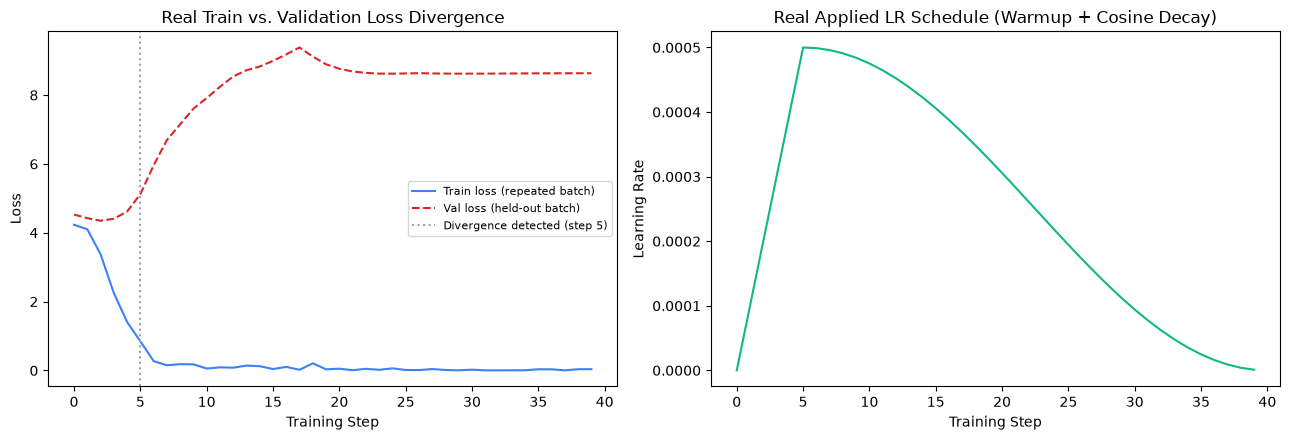

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

steps = range(len(train_losses))
ax1.plot(steps, train_losses, label="Train loss (repeated batch)", color="#3b82f6")
ax1.plot(steps, val_losses, label="Val loss (held-out batch)", color="#dc2626", linestyle="--")
if divergence_step is not None:
    ax1.axvline(divergence_step, color="#94a3b8", linestyle=":", label=f"Divergence detected (step {divergence_step})")
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss")
ax1.set_title("Real Train vs. Validation Loss Divergence")
ax1.legend(fontsize=8)

ax2.plot(steps, lrs, color="#10b981")
ax2.set_xlabel("Training Step")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Real Applied LR Schedule (Warmup + Cosine Decay)")

plt.tight_layout()
plt.show()


### Output Explanation: Visualization
- **Left plot**: the real train (`4.232 → 0.037`) and validation (`4.529 → 8.634`, minimum `4.349` at step 2) loss curves from Section 2, with the real detected divergence marked at step 5 -- the visual signature of overfitting, produced from genuine measurements rather than the illustrative, hand-shaped curve in Module 08's own plot.
- **Right plot**: the actual learning rate applied to the optimizer at every real training step -- ramping `0 → 5e-4` over the first 5 warmup steps, then cosine-decaying to `~1e-6` by step 39 -- confirming Section 2's schedule wasn't just logged but genuinely drove the optimizer.
